# Figures 2-6

## Set-up Cells

In [149]:
import math
import logging
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

In [150]:
###########################################################################
# Change to path to folktexts-replication-results folder on your computer #
###########################################################################

ACS_AGG_RESULTS_ROOT_DIR = Path("/Users/sarahpedersen/Documents/SOC 504/Replication") 
ACS_AGG_RESULTS_PATH = ACS_AGG_RESULTS_ROOT_DIR / "folktexts-replication-results/aggregated_results.csv"
ACS_AGG_RESULTS_PATH = Path(ACS_AGG_RESULTS_PATH)

In [151]:
results_df = pd.read_csv(ACS_AGG_RESULTS_PATH, index_col=0)
print(f"Before filtering: {results_df.shape=}")

# Keep only results that do NOT use the chat template
results_df = results_df[results_df["uses_chat_template"] == False]
print(f"After filtering (no chat template): {results_df.shape=}")

Before filtering: results_df.shape=(16, 73)
After filtering (no chat template): results_df.shape=(12, 73)


In [152]:
ALL_TASKS = [
    "ACSIncome"
]

model_col = "config_model_name"
task_col = "config_task_name"
numeric_prompt_col = "config_numeric_risk_prompting"

Set whether to use **_Numeric_ prompting** or **_multiple-choice Q&A_ prompting**!

In [163]:
NUMERIC_PROMPTING = True

In [164]:
def prettify_model_name(name: str) -> str:
    """Get prettified version of the given model name."""
    dct = {
        "Meta-Llama-3-70B": "Llama 3 70B",
        "Meta-Llama-3-70B-Instruct": "Llama 3 70B (it)",
        "Meta-Llama-3-8B": "Llama 3 8B",
        "Meta-Llama-3-8B-Instruct": "Llama 3 8B (it)",
        "Llama-3-8B": "Llama 3 8B",
        "Llama-3-8B-Instruct": "Llama 3 8B (it)",
        "Llama-3.1-8B": "Llama 3.1 8B",
        "Llama-3.1-8B-Instruct": "Llama 3.1 8B (it)",
        "Mistral-7B-v0.1": "Mistral 7B",
        "Mistral-7B-Instruct-v0.1": "Mistral 7B (it)",
        "gemma-2b": "Gemma 2B",
    }

    if name in dct:
        return dct[name]
    else:
        logging.warning(f"Couldn't find prettified name for {name}.")
        return name

Filter by the currently selected prompting scheme:

In [113]:
import re

def get_model_size_B(model_name: str, default: int = None) -> int:
    """Get the model size from the model name, in Billions of parameters.
    """
    regex = re.search(r"((?P<times>\d+)[xX])?(?P<size>\d+)[bB]", model_name)
    if regex:
        return int(regex.group("size")) * int(regex.group("times") or 1)

    if default is not None:
        return default

    logging.warning(f"Could not infer model size from name '{model_name}'.")
    return default

all_results_df = results_df

all_results_df["model_size"] = [
    (
        get_model_size_B(row["name"], default=300)  # Set GPT 4o size as the largest (300B)
    )
    for _, row in all_results_df.iterrows()
]

def get_model_family(model_name) -> str:
    if "gpt" in model_name.lower():
        return "OpenAI"
    elif "llama" in model_name.lower():
        return "Llama"
    elif "mistral" in model_name.lower() or "mixtral" in model_name.lower():
        return "Mistral"
    elif "gemma" in model_name.lower():
        return "Gemma"
    elif "yi" in model_name.lower():
        return "Yi"
    elif "qwen" in model_name.lower():
        return "Qwen"
    else:
        return "-"

all_results_df["model_family"] = [get_model_family(row[model_col]) for _, row in all_results_df.iterrows()]
all_results_df.groupby([task_col, "model_family"])["accuracy"].count()

config_task_name  model_family
ACSIncome         Gemma           2
                  Llama           6
                  Mistral         4
Name: accuracy, dtype: int64

In [165]:
# Save unfiltered copy (using results_df so re-running this cell is safe)
all_results_df_original = all_results_df if "all_results_df_original" not in dir() else all_results_df_original

all_results_df = all_results_df_original[
    (all_results_df_original[numeric_prompt_col] == NUMERIC_PROMPTING)
    | (all_results_df_original[numeric_prompt_col].isna())
]
print(f"Filtered to {NUMERIC_PROMPTING=}: {all_results_df.shape[0]} rows (from {all_results_df_original.shape[0]})")

Filtered to NUMERIC_PROMPTING=True: 6 rows (from 12)


In [166]:
from matplotlib import pyplot as plt
import seaborn as sns
sns.set_style("whitegrid", rc={"grid.linestyle": "--"})
plt.rc("figure", figsize=(4.5, 3.5), dpi=200)

palette_name = "tab10"   # "colorblind"
palette = sns.color_palette(palette_name)
sns.set_palette(palette_name)
palette

[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
 (0.09019607843137255, 0.7450980392156863, 0.8117647058823529)]

In [167]:
IMGS_DIR = ACS_AGG_RESULTS_PATH.parent / "imgs"
IMGS_DIR.mkdir(exist_ok=True)

def save_fig(fig, name, add_prompt_suffix=True):
    num_or_multiple_choice = "numeric-prompt" if NUMERIC_PROMPTING else "multiple-choice-prompt"
    save_path = (IMGS_DIR / name).with_suffix(".pdf")
    if add_prompt_suffix:
        save_path = save_path.with_suffix(f".{num_or_multiple_choice}.pdf")

    fig.savefig(save_path, bbox_inches="tight")
    print(f"Saved figure to '{save_path.as_posix()}'")

Load scores distributions for each model (and with varying degrees of information).

In [168]:
predictions_path_col = "predictions_path"

def load_model_scores_df(df_row: pd.Series) -> pd.DataFrame:
    """Loads csv containing model scores corresponding to the given DF row."""
    if predictions_path_col in df_row and not pd.isna(df_row[predictions_path_col]):
        return pd.read_csv(ACS_AGG_RESULTS_ROOT_DIR / df_row[predictions_path_col], index_col=0)
    return None

In [169]:
scores_df_map = {
    id_: load_model_scores_df(row)
    for id_, row in tqdm(all_results_df.iterrows(), total=len(all_results_df))
}

100%|██████████| 6/6 [00:00<00:00, 49.05it/s]


## Figure 3: Calibration curves

In [170]:
TASK = "ACSIncome"

df = all_results_df[(all_results_df[task_col] == TASK) & (all_results_df[numeric_prompt_col] == NUMERIC_PROMPTING)]

Saved figure to '/Users/sarahpedersen/Documents/SOC 504/Replication/folktexts-replication-results/imgs/figure_3_calibration_curves.numeric-prompt.pdf'


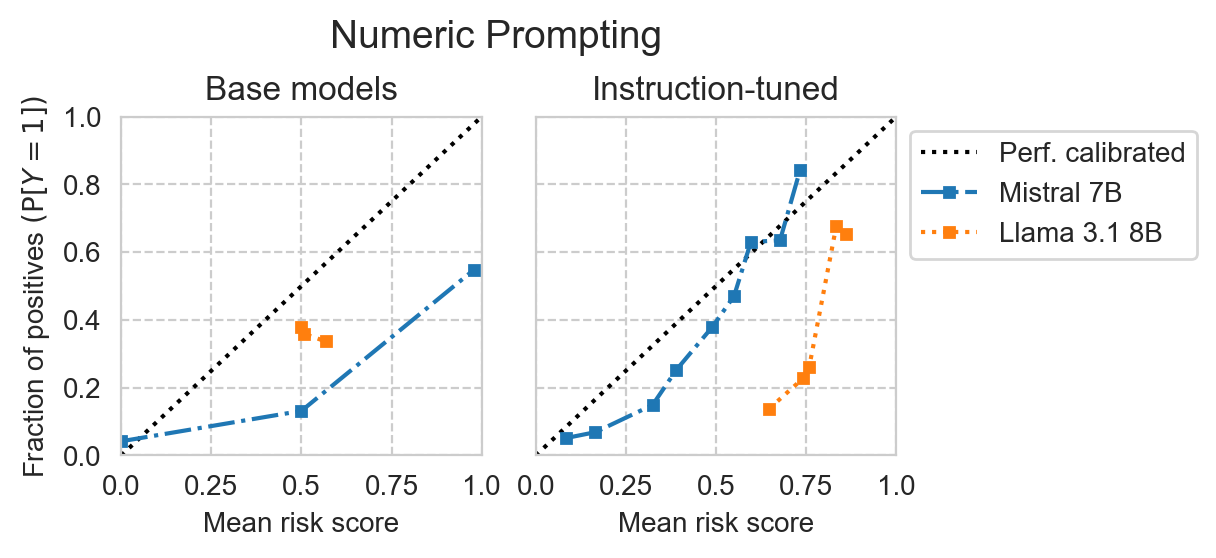

In [171]:
from sklearn.calibration import CalibrationDisplay

# Only include base models that have a corresponding instruct model in the data
base_models_to_plot = [
    m for m in df["base_name"].unique()
    if "gemma" not in m.lower()
    and len(df[(df["base_name"] == m) & (df[model_col] != m)]) > 0
]

instr_models_to_plot = [
    df[
        (df["base_name"] == m)
        & (df[model_col] != m)
    ][model_col].iloc[0]
    for m in base_models_to_plot
]

fig, axes = plt.subplots(ncols=2, figsize=(5, 2.2), gridspec_kw=dict(wspace=0.15), sharey=True)

# Plot base models
for ax, model_list in zip(axes, (base_models_to_plot, instr_models_to_plot)):
    
    for idx, m in enumerate(model_list):

        curr_row = df[df[model_col] == m].iloc[0]
        curr_scores = scores_df_map[curr_row.name]

        disp = CalibrationDisplay.from_predictions(
            y_true=curr_scores["label"],
            y_prob=curr_scores["risk_score"],
            n_bins=10,
            strategy="quantile",
            name=prettify_model_name(curr_row["base_name"]),
            linestyle=["-.", ":", "--"][idx % 3],
            ax=ax,
            ms=3.5,
        )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

ylabel = "Fraction of positives " + r"$\left(\mathrm{P}[Y=1]\right)$"
axes[0].set_ylabel(ylabel)
axes[1].set_ylabel("")

xlabel = "Mean risk score"
axes[0].set_xlabel(xlabel)
axes[1].set_xlabel(xlabel)

axes[0].set_title("Base models")
axes[1].set_title("Instruction-tuned")

# Set prettier x ticks
xticks = (0, 0.25, 0.5, 0.75, 1)
xticks_labels = ("0.0", "0.25", "0.5", "0.75", "1.0")
axes[0].set_xticks(xticks, labels=xticks_labels)
axes[1].set_xticks(xticks, labels=xticks_labels)

axes[0].legend().remove()

# Legend to the right of the right-most plot
if NUMERIC_PROMPTING:
    h, l = axes[1].get_legend_handles_labels()
    l[0] = "Perf. calibrated"
    axes[1].legend(handles=h, labels=l, loc="upper left", bbox_to_anchor=(1, 1))
else:
    axes[1].legend().remove()

# Figure title
if NUMERIC_PROMPTING:
    title = "Numeric Prompting"
else:
    title = "Multiple-choice Prompting"
plt.suptitle(title, y=1.1, fontsize=14)

plt.plot()

save_fig(fig, f"figure_3_calibration_curves.pdf")

## Figure 5: Score distributions for base/instruct pairs

In [172]:
task = "ACSIncome"

task_df = all_results_df[
    (all_results_df[task_col] == task)
    & (
        (all_results_df[numeric_prompt_col] == NUMERIC_PROMPTING)
        | (all_results_df[numeric_prompt_col].isna())                  # Baseline models will have NaNs in this col.
    )]

sorted_model_families = ["Llama", "Mistral", "Gemma", "-"]

model_pairs = sorted([
        (row["base_name"], row[model_col])
        for id_, row in task_df[task_df["is_inst"] == True].iterrows()
    ],
    key=lambda val: (
        1e6 * sorted_model_families.index((row := task_df[task_df[model_col] == val[0]].iloc[0])["model_family"])
        + row["model_size"]
    )
)

Saved figure to '/Users/sarahpedersen/Documents/SOC 504/Replication/folktexts-replication-results/imgs/figure_5_score_distribution.numeric-prompt.pdf'


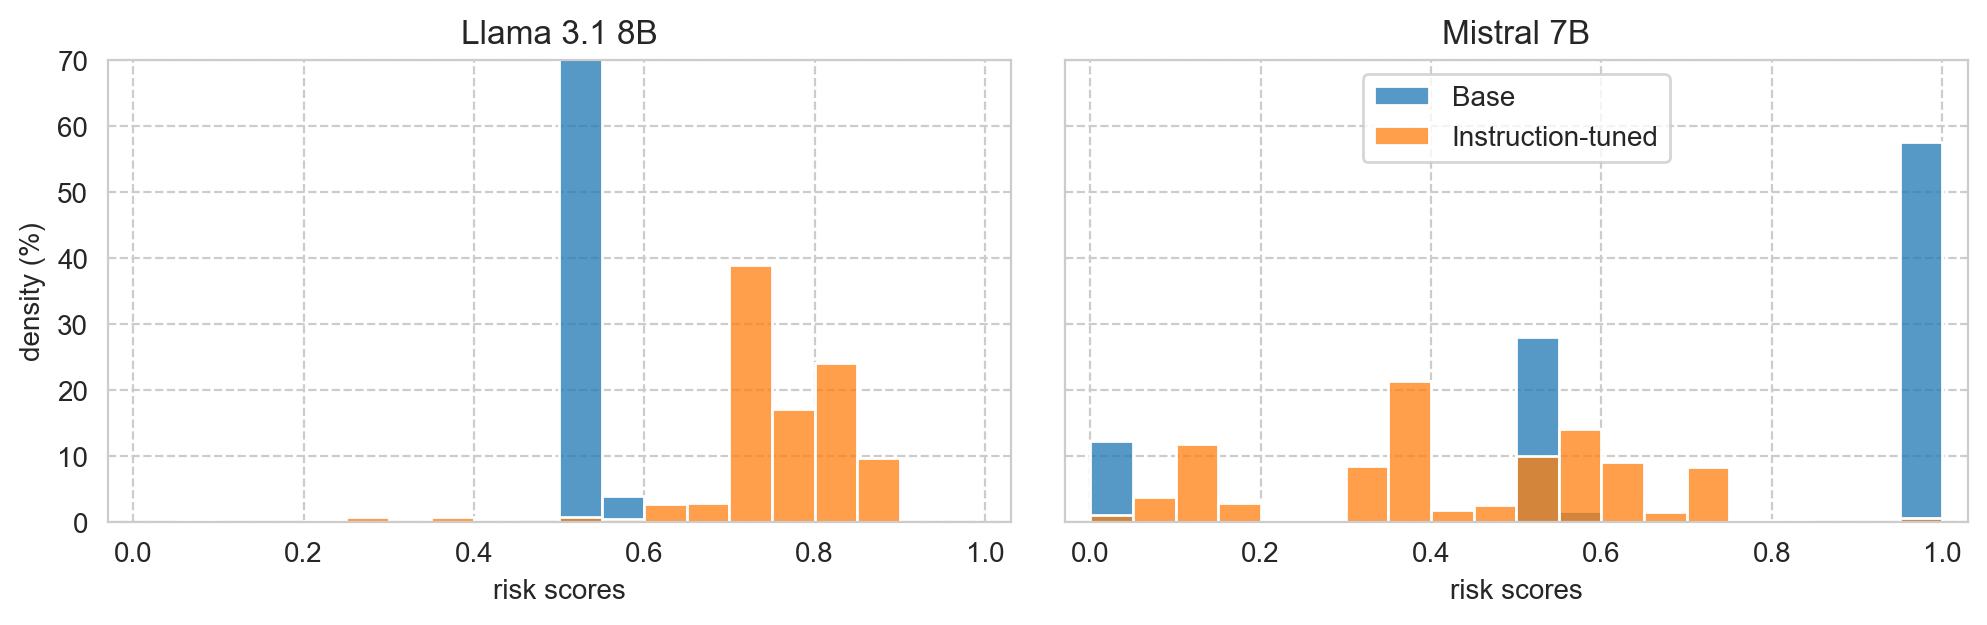

In [173]:
PLOT_THRESHOLD_LINE = False

N_PLOTS = len(model_pairs)

N_COLS = N_PLOTS
N_ROWS = math.ceil(N_PLOTS / N_COLS)
N_BINS = 20

fig, axes = plt.subplots(
    nrows=N_ROWS, ncols=N_COLS,
    figsize=(12, 3 * N_ROWS),
    sharey=True, sharex=False,
    gridspec_kw=dict(
        hspace=0.5,
        wspace=0.06,
    ),
)

# Plot settings
plot_config = dict(
    bins=N_BINS,
    binrange=(0, 1),
    stat="percent",
)

# Plot score distribution for model pairs
for idx, (base_name, instr_name) in enumerate(model_pairs):
    ax_row = idx // N_COLS
    ax_col = idx % N_COLS

    ax = axes[ax_row, ax_col] if N_ROWS > 1 else axes[ax_col]

    base_row = task_df[task_df[model_col] == base_name].iloc[0]
    it_row = task_df[task_df[model_col] == instr_name].iloc[0]

    # Get scores
    base_scores = scores_df_map[base_row.name]["risk_score"]
    it_scores = scores_df_map[it_row.name]["risk_score"]

    ax.set_title(base_row["name"])

    ax.set_xlabel("risk scores")
    if ax_col == 0:
        ax.set_ylabel("density (%)")

    if ax_row == 0:
        ax.set_ylim(0, 70)

    ax.set_xlim(-0.03, 1.03)

    # Render plot
    if "gpt" not in instr_name.lower():
        sns.histplot(base_scores, label="Base", color=palette[0], ax=ax, **plot_config)
    sns.histplot(it_scores, label="Instruction-tuned", color=palette[1], ax=ax, **plot_config)

    # Draw faint vertical line with t^* of each model
    threshold_col = "optimal_thresh"

    if PLOT_THRESHOLD_LINE:
        ax.axvline(x=base_row[threshold_col], ls="--", color=palette[0], alpha=0.5)
        ax.axvline(x=it_row[threshold_col], ls="--", color=palette[1], alpha=0.5)

    # Render legend on a few sub-plots
    if (ax_col == 0 and ax_row == 1) or (ax_col == N_COLS-1 and ax_row == 0):
        ax.legend(loc="upper center")

        if PLOT_THRESHOLD_LINE:
            ax.text(
                x=base_row[threshold_col] - 5e-2,
                y=43,
                s="$t^*$",
                color=palette[0],
                fontsize=10,
                ha='center',
                va='bottom',
            )
            
            ax.text(
                x=it_row[threshold_col] + 5e-2,
                y=43,
                s="$t^*$",
                color=palette[1],
                fontsize=10,
                ha='center',
                va='bottom',
            )

# Hide any unused subplot axes
if N_ROWS > 1:
    for idx in range(N_PLOTS, N_ROWS * N_COLS):
        axes[idx // N_COLS, idx % N_COLS].set_visible(False)

plt.plot()

# Save figure
save_fig(fig, f"figure_5_score_distribution")

## Figure 6: Calibration per sub-group

In [174]:
# takes ~2 minutes to run and downloads lots of files :)
from folktexts.acs import ACSDataset

DATA_DIR = ACS_AGG_RESULTS_ROOT_DIR / "folktexts-replication-results"

acs_dataset = ACSDataset.make_from_task(task=TASK, cache_dir=DATA_DIR)

Loading ACS data...


/Users/sarahpedersen/miniconda3/envs/folktexts/lib/python3.11/site-packages/folktexts/acs/acs_dataset.py:158: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  parsed_df[task.get_target()] = task.target_threshold.apply_to_column_data(parsed_df[task.target])


In [175]:
# Omit small groups from the plots (results can be too noisy)
OMIT_GROUPS_BELOW_PCT = 4
N_BINS = 10

In [176]:
sens_attr_col = "RAC1P"
sens_attr_map = {
    1: "White",
    2: "Black",
    6: "Asian",
    # 8: "Other",   # some other race alone
}

name_to_sens_attr_map = {val: key for key, val in sens_attr_map.items()}

def plot_cali_curve(model_id, ax, df):
    """Plot sub-group calibration curves using sklearn"""

    curr_row = df.loc[model_id]
    curr_scores_df = scores_df_map[curr_row.name]

    y_true = curr_scores_df["label"].to_numpy()
    y_scores = curr_scores_df["risk_score"].to_numpy()

    sens_attr = acs_dataset.data.loc[curr_scores_df.index][sens_attr_col].to_numpy()

    for idx, group_val in enumerate(np.unique(sens_attr)):
        group_filter = sens_attr == group_val

        if np.sum(group_filter) < len(group_filter) * 0.01 * OMIT_GROUPS_BELOW_PCT:
            # print(f"Skipping group={group_val}")
            continue

        disp = CalibrationDisplay.from_predictions(
            y_true=y_true[group_filter],
            y_prob=y_scores[group_filter],
            n_bins=N_BINS,
            # strategy="uniform",
            strategy="quantile",
            name=str(sens_attr_map.get(group_val, group_val)),
            linestyle=["-.", ":", "--"][idx % 3],
            ax=ax,
        )

    # Set other plot settings
    ax.set_title(curr_row["name"])
    return disp

 50%|█████     | 1/2 [00:01<00:01,  1.15s/it]

Saved figure to '/Users/sarahpedersen/Documents/SOC 504/Replication/folktexts-replication-results/imgs/figure_6_subgroup_calibration.numeric-prompt.pdf'


100%|██████████| 2/2 [00:02<00:00,  1.03s/it]

Saved figure to '/Users/sarahpedersen/Documents/SOC 504/Replication/folktexts-replication-results/imgs/figure_6_subgroup_calibration.numeric-prompt.pdf'


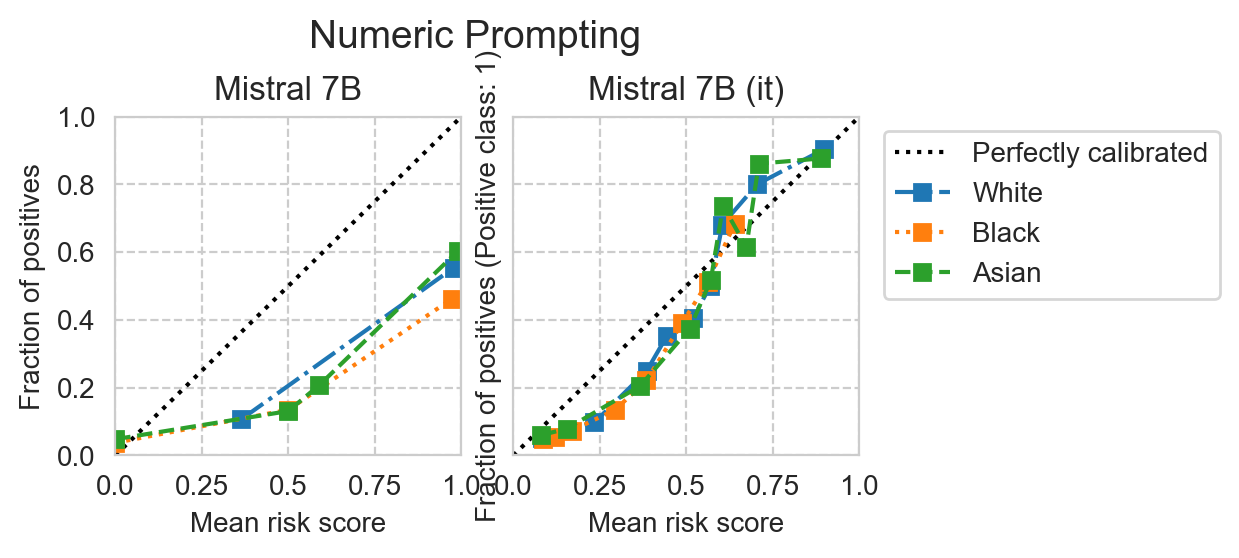

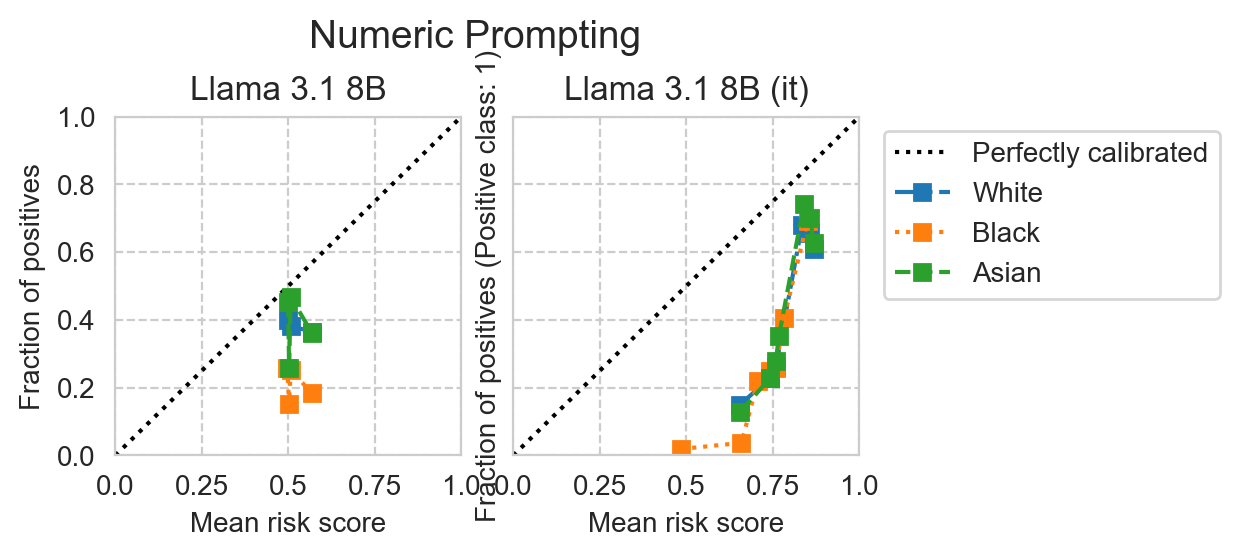

In [177]:
from sklearn.calibration import CalibrationDisplay

# Get results for the current task
task_df = all_results_df[all_results_df[task_col] == TASK]

# Dynamically get base/instruct model pairs (exclude gemma)
base_models_to_plot = [
    m for m in df["base_name"].unique()
    if "gemma" not in m.lower()
    and len(df[(df["base_name"] == m) & (df[model_col] != m)]) > 0
]

instr_models_to_plot = [
    df[
        (df["base_name"] == m)
        & (df[model_col] != m)
    ][model_col].iloc[0]
    for m in base_models_to_plot
]

base_it_pairs = list(zip(base_models_to_plot, instr_models_to_plot))

for base_model, it_model in tqdm(base_it_pairs):
    fig, axes = plt.subplots(ncols=2, figsize=(4.8, 2.2), gridspec_kw=dict(wspace=0.15), sharey=True)

    for idx, ax, m in zip(range(len(axes)), axes, (base_model, it_model)):
        if m is None:
            ax.remove()
            continue

        curr_row = task_df[(task_df[model_col] == m) & (task_df["uses_all_features"])].iloc[0]
        curr_id = curr_row.name

        # Plot with confidence intervals:
        plot_cali_curve(curr_id, ax=ax, df=task_df)
        
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

        ax.set_xlabel("Mean risk score")
        if idx == 0:
            ax.set_ylabel("Fraction of positives")

        # Set prettier x-ticks
        xticks = (0, 0.25, 0.5, 0.75, 1)
        xticks_labels = ("0.0", "0.25", "0.5", "0.75", "1.0")
        ax.set_xticks(xticks, labels=xticks_labels)

    # Prepare legend
    axes[0].legend().remove()
    if NUMERIC_PROMPTING:
        axes[1].legend(loc="best", bbox_to_anchor=(1.03, 1))
    else:
        axes[1].legend().remove()

    # Figure title
    if NUMERIC_PROMPTING:
        title = "Numeric Prompting"
    else:
        title = "Multiple-choice Prompting"

    # Don't use suptitle for GPT4 (no base model)
    if base_model is not None:
        plt.suptitle(title, y=1.1, fontsize=14)
    else:
        model_title = axes[1].get_title()
        plt.title(f"{title}\n{model_title}")
    
    plt.plot()
    save_fig(fig, f"figure_6_subgroup_calibration.pdf")

## Figure 4: Risk score confidence bias

In [178]:
def compute_confidence_bias_metric_helper(data):
    """Helper to compute the under- / over-confidence metric.
    """
    mean_label = data["label"].mean()
    mean_score = data["risk_score"].mean()

    if mean_score < 0.5:
        return ((1 - mean_score) - (1 - mean_label))
    else:
        return (mean_score - mean_label)

def compute_confidence_bias_metric(model_id, quantiled_bins=False, scores_df=None):
    if scores_df is None:
        scores_df = scores_df_map[model_id]

    discretization_func = pd.qcut if quantiled_bins else pd.cut
    scores_df["score_bin"] = discretization_func(scores_df["risk_score"], 10, labels=range(10))
    
    bias_metric_val = (1 / len(scores_df)) * sum(
        len(bin_data) * compute_confidence_bias_metric_helper(bin_data)
        for bin_ in range(10)
        if len(bin_data := scores_df[scores_df["score_bin"] == bin_]) > 0
    )
    return float(bias_metric_val)

In [179]:
confidence_scores = {
    m: compute_confidence_bias_metric(m)
    for m in tqdm(scores_df_map.keys())
}

100%|██████████| 6/6 [00:00<00:00, 105.30it/s]


In [180]:
all_results_df["under_over_score"] = all_results_df.apply(lambda row: confidence_scores[row.name], axis=1)
all_results_df.sort_values("under_over_score", ascending=True)["under_over_score"]

Mistral-7B-Instruct-v0.1__ACSIncome__-1__Num_   -0.064879
Llama-3.1-8B__ACSIncome__-1__Num_                0.137224
Llama-3-8B__ACSIncome__-1__Num_                  0.170796
Mistral-7B-v0.1__ACSIncome__-1__Num_             0.364873
gemma-2b__ACSIncome__-1__Num_                    0.367051
Llama-3.1-8B-Instruct__ACSIncome__-1__Num_       0.370767
Name: under_over_score, dtype: float64

Saved figure to '/Users/sarahpedersen/Documents/SOC 504/Replication/folktexts-replication-results/imgs/figure_4_confidence_bias.numeric-prompt.pdf'


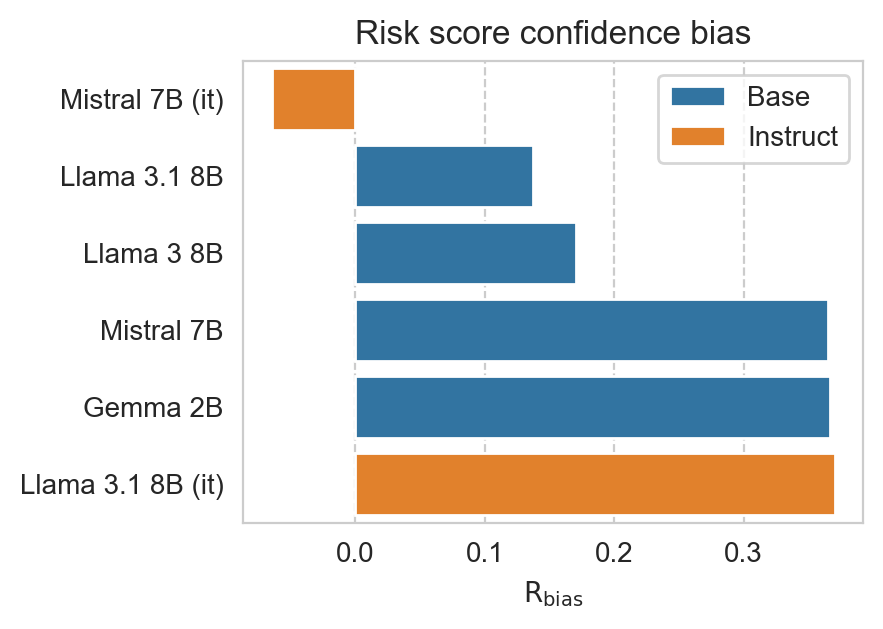

In [181]:
TASK = "ACSIncome"

plot_df = all_results_df[
    (all_results_df[task_col] == TASK)
    & (~all_results_df[numeric_prompt_col].isna())
]

fig, ax = plt.subplots(figsize=(4, 3))
sns.barplot(
    data=plot_df.sort_values("under_over_score", ascending=True),
    x="under_over_score",
    y="name",
    # y=task_col,
    hue="is_inst",
    ax=ax,
)

handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=["Base", "Instruct"])

plt.ylabel("")
plt.xlabel(r"$\mathrm{R}_\mathrm{bias}$")

plt.title(f"Risk score confidence bias")

save_fig(fig, f"figure_4_confidence_bias.pdf")

## Figure 2: Change in ECE

In [131]:
IT_OR_BASE = "any"
METRIC = "ece"


In [132]:
def model_sort_key(name, task_df):
    """Sort key for paper table rows."""

    if "llama" in name.lower():
        key = 10
    elif "mistral" in name.lower():
        key = 8
    elif "gemma" in name.lower():
        key = 6
    else:
        return 0

    row = task_df.loc[name]
    # return (1e5 * key) + (row["model_size"] * 100) + int(row["is_inst"] * 10) + (1 if row[numeric_prompt_col] else 0)
    return (row["model_size"] * 1e9) + int(row["is_inst"] * 1e6) + 1e3 * (1 if row[numeric_prompt_col] else 0) + key


In [133]:
# Prepare data
df = all_results_df_original.copy()

min_max_per_task = {
    task: (np.min(values), np.max(values))
    for task in ALL_TASKS
    if len(values := df[(df[task_col] == task) & (~df[numeric_prompt_col].isna())][METRIC]) > 0
}

# Sort models
sorted_df_index = sorted(
    df.index.tolist(),
    key=lambda id_: model_sort_key(id_, df),
    reverse=True,
)
df = df.loc[sorted_df_index]

if IT_OR_BASE == "it":
    print("Plotting IT models")
    df = df[df["is_inst"] == True]
elif IT_OR_BASE == "base":
    print("Plotting BASE models")
    df = df[df["is_inst"] == False]
else:
    print("Plotting ALL models")
    df = df.sort_values(by=["is_inst", "model_size"], ascending=False)

# Data for multiple-choice prompting
df_mult_choice = df[df[numeric_prompt_col] == False].set_index(["name", task_col], drop=False)

# Data for numeric risk prompting
df_numeric = df[df[numeric_prompt_col] == True].set_index(["name", task_col], drop=False)

# Sorted list of model names
model_names = df_numeric["name"].unique().tolist()[::-1]
n_models = len(model_names)
print(f"{model_names=}")

Plotting ALL models
model_names=['Gemma 2B', 'Mistral 7B', 'Llama 3.1 8B', 'Llama 3 8B', 'Mistral 7B (it)', 'Llama 3.1 8B (it)']


Saved figure to '/Users/sarahpedersen/Documents/SOC 504/Replication/folktexts-replication-results/imgs/figure_2_ece_change.pdf'


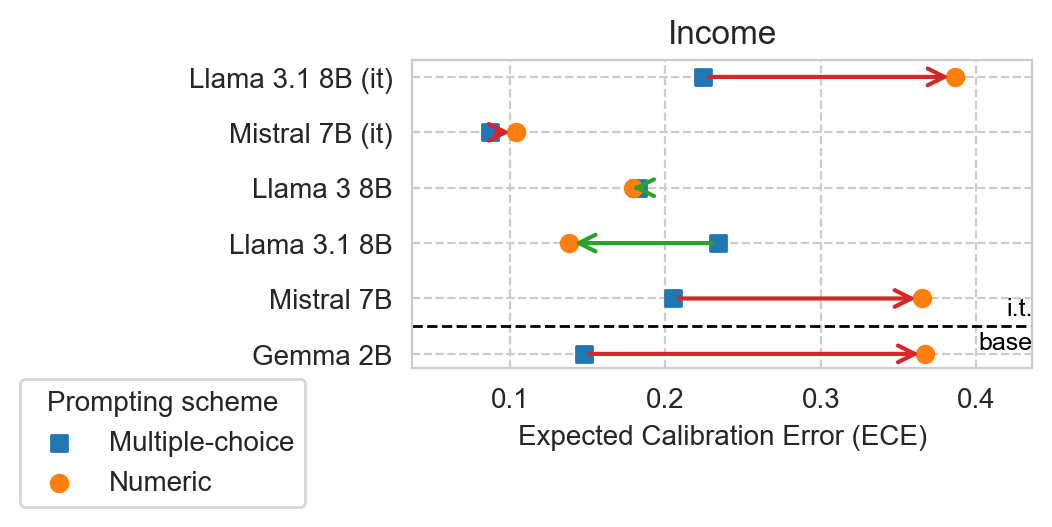

In [135]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

task = TASK

# Create a figure and axis
fig, ax = plt.subplots(figsize=(4, n_models / 3))

# Plot arrows for each model
for i, model_name in enumerate(model_names):

    curr_mult_choice_metric = df_mult_choice.loc[model_name, task][METRIC]
    curr_numeric_metric = df_numeric.loc[model_name, task][METRIC]
    
    ax.scatter(
        curr_mult_choice_metric, i,
        color=palette[0], marker="s",
        label='Multiple-choice' if i == 0 else "",
    )
    ax.scatter(
        curr_numeric_metric, i,
        color=palette[1], marker="o",
        label='Numeric' if i == 0 else "",
    )

    # Draw a FancyArrowPatch arrow from before to after fine-tuning
    if METRIC == "ece":
        curr_metric_improved = curr_numeric_metric <= curr_mult_choice_metric
    else:
        curr_metric_improved = curr_numeric_metric >= curr_mult_choice_metric
    
    arrow = FancyArrowPatch(
        (curr_mult_choice_metric, i), (curr_numeric_metric, i),
        arrowstyle='->',
        color=palette[2] if curr_metric_improved else palette[3],
        mutation_scale=15,
        lw=1.5,
    )
    ax.add_patch(arrow)

    # Set axes ranges according to overall min/max values
    lo, hi = min_max_per_task[task]
    if METRIC == "ece":
        lo = max(lo - 5e-2, 0)
        hi = min(hi + 5e-2, 0.475)
    elif METRIC == "roc_auc":
        lo = max(lo - 5e-2, 0.475)
        hi = min(hi + 4e-2, 1)

    if task == "ACSIncome" and METRIC == "roc_auc":
        lo = 0.58
    ax.set_xlim(lo, hi)

# Set y-ticks and y-labels
ax.set_yticks(range(n_models))
ax.set_yticklabels(model_names)

# Add labels and title
ax.set_title(task[3:])

# Add horizontal line separating instruct and base models
if IT_OR_BASE == "any":
    n_instruct_models = len(df_mult_choice[(df_mult_choice["is_inst"] == True) & (df_mult_choice[task_col] == task)])
    line_y = n_instruct_models - 1.5
    ax.axhline(line_y, color='black', linestyle='--', linewidth=1)

    text_kwargs = dict(
        horizontalalignment='right',
        transform=ax.get_yaxis_transform(),
        fontsize=9, color='black',
    )
    ax.text(1, line_y + 0.1, 'i.t.', verticalalignment='bottom', **text_kwargs)
    ax.text(1, line_y - 0.1, 'base', verticalalignment='top', **text_kwargs)

# Add legend
ax.legend(loc="upper right", bbox_to_anchor=(-0.15, 0.01), title="Prompting scheme")

# X-axis label
if METRIC == "ece":
    x_axis_label = "Expected Calibration Error (ECE)"
elif METRIC == "roc_auc":
    x_axis_label = "Predictive Power (ROC AUC)"

ax.set_xlabel(x_axis_label)

# Save figure
save_fig(fig=fig, name=f"figure_2_ece_change.pdf", add_prompt_suffix=False)

plt.show()